# CURRENT PIPELINE

In [1]:
from __future__ import annotations
 
import os
import re
import json
import hashlib
import datetime
import importlib
import warnings
from typing import Any
 
import numpy as np
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
 
warnings.filterwarnings("ignore")
 
# ── Local KB modules ──────────────────────────────────────────────────────────
import kb0_ticker_resolver
import kb1_generate_tickers
import kb2_macro_regime
import kb3_concepts
import kb4_strategies
 
for _mod in [kb0_ticker_resolver, kb1_generate_tickers,
             kb2_macro_regime, kb3_concepts, kb4_strategies]:
    importlib.reload(_mod)
 
from kb0_ticker_resolver import resolve_tickers_from_query
from kb1_generate_tickers import (
    generate_tickers,
    convert_tickers_into_txt,
    build_ticker_meta as _build_ticker_meta,
    OUTPUT_DIR_HTML, OUTPUT_TXT
)
from kb2_macro_regime import MacroStore
from kb3_concepts  import ConceptStore
from kb4_strategies import StrategyStore

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
VECTOR_DB_DIR       = "vector_db"
EMBED_MODEL_NAME    = "sentence-transformers/all-MiniLM-L6-v2"
KB_STALENESS_HOURS  = 24
RELEVANCE_THRESHOLD = 0.10    # lower than before — static KB chunks score differently
RETRIEVAL_LOG_DIR   = "retrieval_log"
 
# ── Intent → KB source mapping ────────────────────────────────────────────────
# Each intent specifies which Chroma collections to query
INTENT_SOURCES: dict[str, list[str]] = {
    "full_analysis":     ["tickers", "strategies"],
    "concept_explanation": ["concepts", "strategies"],
    "trend_prediction":  ["tickers", "macro"],
    "fallback":          ["tickers", "macro", "concepts", "strategies"],
}
 
# Collection name → display label
COLLECTION_LABELS = {
    "tickers":    "Ticker Profiles (yfinance)",
    "macro":      "Macro & Regime (FRED + yfinance)",
    "concepts":   "Concept Definitions",
    "strategies": "Strategy Frameworks",
}

In [3]:
# =============================================================================
# SECTION 1 — KB SOURCE MANAGEMENT
# =============================================================================
 
def _kb1_file_path(ticker: str) -> str:
    return os.path.join(OUTPUT_DIR_HTML, f"{ticker.lower()}.html")
 
 
def _kb1_is_fresh(ticker: str) -> bool:
    path = _kb1_file_path(ticker)
    if not os.path.exists(path):
        return False
    age = (datetime.datetime.now().timestamp() - os.path.getmtime(path)) / 3600
    return age < KB_STALENESS_HOURS
 
 
def _ensure_kb1_files(tickers: list[str], force: bool = False) -> None:
    to_gen = {}
    for t in tickers:
        if force or not _kb1_is_fresh(t):
            meta = _build_ticker_meta(t)
            if meta:
                to_gen[t] = meta
            else:
                print(f" Cannot resolve meta for {t}")
        else:
            print(f"  ✓ {t}: ticker KB fresh")
    if to_gen:
        generate_tickers(to_gen)
        convert_tickers_into_txt()
 
 
def _load_kb1_documents() -> list[dict]:
    """
    Load ticker profile chunks by running kb1's full pipeline:
    HTML → strip tags → clean text → convert numbers → return chunks.
    Cleaning is applied inside convert_tickers_into_txt(), so what goes
    into Chroma is identical to what is written to the TXT audit file.
    """
    if not os.path.exists(OUTPUT_DIR_HTML) or not os.listdir(OUTPUT_DIR_HTML):
        return []
    return convert_tickers_into_txt(output_txt=OUTPUT_TXT)
 
 
def _collect_all_chunks(
    intent:           str,
    resolved_tickers: list[str],
    macro_store:      MacroStore     | None = None,
    concept_store:    ConceptStore   | None = None,
    strategy_store:   StrategyStore  | None = None,
    force_refresh:    bool           = False,
) -> list[dict]:
    """
    Gather chunks from all KB sources relevant to the detected intent.
 
    Returns a flat list of chunk dicts, each with:
      kb_source, text, citation_id, source_url, source_type, intent_tags
    """
    sources   = INTENT_SOURCES.get(intent, INTENT_SOURCES["fallback"])
    all_chunks: list[dict] = []
 
    # ── kb1: Ticker profiles ───────────────────────────────────────────────
    if "tickers" in sources and resolved_tickers:
        print(f"  📥 kb1: loading ticker profiles for {resolved_tickers}")
        _ensure_kb1_files(resolved_tickers, force=force_refresh)
        kb1_docs = _load_kb1_documents()
        # Filter to only resolved tickers for this query
        filtered = [
            d for d in kb1_docs
            if d.get("ticker", "").upper() in [t.upper() for t in resolved_tickers]
        ]
        # Attach citation fields if missing
        for i, d in enumerate(filtered):
            if "citation_id" not in d:
                d["citation_id"] = f"ticker-{d['ticker']}-{i}"
        all_chunks.extend(filtered)
        print(f"    → {len(filtered)} ticker chunks")
 
    # ── kb2: Macro ─────────────────────────────────────────────────────────
    if "macro" in sources and macro_store is not None:
        print("  📥 kb2: loading macro chunks + writing TXT")
        if force_refresh or macro_store._is_stale():
            macro_store.refresh(force=force_refresh)
        chunks = macro_store.generate_chunks()
        macro_store.export_txt()
        all_chunks.extend(chunks)
        print(f"    → {len(chunks)} macro chunks")
 
    # ── kb3: Concepts ──────────────────────────────────────────────────────
    if "concepts" in sources and concept_store is not None:
        print("  📥 kb3: loading concept chunks + writing TXT")
        chunks = concept_store.generate_chunks()
        concept_store.export_txt()
        all_chunks.extend(chunks)
        print(f"    → {len(chunks)} concept chunks")
 
    # ── kb4: Strategies ────────────────────────────────────────────────────
    if "strategies" in sources and strategy_store is not None:
        print("  📥 kb4: loading strategy chunks + writing TXT")
        chunks = strategy_store.generate_chunks()
        strategy_store.export_txt()
        all_chunks.extend(chunks)
        print(f"    → {len(chunks)} strategy chunks")
 
    print(f"  Total chunks in pool: {len(all_chunks)}")
    return all_chunks

In [4]:
# =============================================================================
# SECTION 2 — CHROMA: MULTI-COLLECTION MANAGEMENT
# =============================================================================
 
def _get_or_create_collection(
    client:     chromadb.PersistentClient,
    name:       str,
    documents:  list[dict],
    model:      SentenceTransformer,
) -> chromadb.Collection:
    collection = client.get_or_create_collection(name=name)
    if not documents:
        return collection

    texts      = [d["text"] for d in documents]
    metadatas  = [
        {
            "kb_source":   d.get("kb_source", name),
            "ticker":      d.get("ticker", ""),
            "source_type": d.get("source_type", ""),
            "citation_id": d.get("citation_id", ""),
        }
        for d in documents
    ]
    ids        = [str(i) for i in range(len(documents))]
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)

    try:
        collection.upsert(
            documents=texts,
            embeddings=embeddings.tolist(),
            metadatas=metadatas,
            ids=ids,
        )
    except Exception as e:
        print(f"  ⚠ Upsert failed for '{name}': {e}")
        print(f"  🔄 Deleting and recreating collection '{name}'...")
        client.delete_collection(name)
        collection = client.get_or_create_collection(name=name)
        collection.upsert(
            documents=texts,
            embeddings=embeddings.tolist(),
            metadatas=metadatas,
            ids=ids,
        )

    return collection
 
 
def _build_collections(
    all_chunks: list[dict],
    model:      SentenceTransformer,
    client:     chromadb.PersistentClient,
) -> dict[str, chromadb.Collection]:
    """
    Group chunks by kb_source and upsert into separate Chroma collections.
    Returns { collection_name: Collection }.
    """
    grouped: dict[str, list[dict]] = {}
    for chunk in all_chunks:
        src = chunk.get("kb_source", "unknown")
        grouped.setdefault(src, []).append(chunk)
 
    collections = {}
    for src, docs in grouped.items():
        print(f"  🔢 Embedding {len(docs)} chunks → collection '{src}'")
        collections[src] = _get_or_create_collection(client, src, docs, model)
    return collections

In [5]:
# =============================================================================
# SECTION 3 — HYBRID RETRIEVAL (MULTI-COLLECTION)
# =============================================================================
 
def _hybrid_retrieve_multi(
    query:       str,
    all_chunks:  list[dict],
    collections: dict[str, chromadb.Collection],
    model:       SentenceTransformer,
    top_k:       int   = 8,
    bm25_weight: float = 0.3,
    vec_weight:  float = 0.7,
) -> list[dict]:
    """
    Hybrid BM25 + vector search across all loaded chunks.
    BM25 operates on the full chunk pool; vector search queries each collection
    separately then merges. Scores are fused and globally ranked.
    """
    if not all_chunks:
        return []
 
    texts = [d["text"] for d in all_chunks]
    n     = len(texts)
 
    # ── BM25 across full pool ─────────────────────────────────────────────────
    bm25     = BM25Okapi([t.split() for t in texts])
    bm25_raw = bm25.get_scores(query.split())
    b_min, b_max = bm25_raw.min(), bm25_raw.max()
    bm25_norm = (
        (bm25_raw - b_min) / (b_max - b_min)
        if b_max > b_min else np.zeros(n)
    )
 
    # ── Vector search per collection ──────────────────────────────────────────
    q_emb          = model.encode([query], convert_to_numpy=True)
    vec_scores_raw = np.zeros(n)
 
    # Build a mapping from chunk text → index for vector result matching
    text_to_idx = {text: i for i, text in enumerate(texts)}
 
    # Track which indices have been assigned in each collection
    offset = 0
    col_offsets: dict[str, int] = {}
    for src, docs in _group_by_source(all_chunks):
        col_offsets[src] = offset
        offset += len(docs)
 
    for src, collection in collections.items():
        src_docs  = [c for c in all_chunks if c.get("kb_source") == src]
        n_src     = len(src_docs)
        if n_src == 0:
            continue
        n_results = min(max(top_k, n_src // 2), n_src)
        try:
            results = collection.query(
                query_embeddings=q_emb.tolist(),
                n_results=n_results,
                include=["distances", "documents"],
            )
            for doc_text, dist in zip(
                results["documents"][0],
                results["distances"][0],
            ):
                idx = text_to_idx.get(doc_text)
                if idx is not None:
                    vec_scores_raw[idx] = max(
                        vec_scores_raw[idx],
                        1.0 / (1.0 + dist)
                    )
        except Exception as e:
            print(f"  Vector search failed for '{src}': {e}")
 
    v_min, v_max = vec_scores_raw.min(), vec_scores_raw.max()
    vec_norm = (
        (vec_scores_raw - v_min) / (v_max - v_min)
        if v_max > v_min else np.zeros(n)
    )
 
    # ── Fusion ────────────────────────────────────────────────────────────────
    fused       = bm25_weight * bm25_norm + vec_weight * vec_norm
    top_indices = fused.argsort()[-top_k:][::-1]
 
    return [
        {
            **all_chunks[i],
            "rank":     int(rank + 1),
            "score":    float(fused[i]),
            "bm25_raw": float(bm25_raw[i]),
            "vec_sim":  float(vec_scores_raw[i]),
        }
        for rank, i in enumerate(top_indices)
    ]
 
 
def _group_by_source(chunks: list[dict]) -> list[tuple[str, list[dict]]]:
    """Return chunks grouped by kb_source, preserving insertion order."""
    seen:   dict[str, list[dict]] = {}
    for c in chunks:
        src = c.get("kb_source", "unknown")
        seen.setdefault(src, []).append(c)
    return list(seen.items())

In [6]:
# =============================================================================
# SECTION 4 — POST-PROCESSING
# =============================================================================
 
def _post_process(
    results:          list[dict],
    resolved_tickers: list[str],
    score_threshold:  float = RELEVANCE_THRESHOLD,
) -> list[dict]:
    """
    Option 1 — Relevance Filtering: drop chunks below score_threshold.
    Option 2 — Citation Enforcement: attach citation metadata to all survived chunks.
    """
    processed = []
    for chunk in results:
        if chunk["score"] < score_threshold:
            print(
                f"  ✂  Filtered [{chunk.get('kb_source','?')}] "
                f"rank={chunk['rank']} score={chunk['score']:.3f}"
            )
            continue
 
        # Ensure citation fields are present
        if "citation_id" not in chunk or not chunk["citation_id"]:
            chunk["citation_id"] = f"{chunk.get('kb_source','kb')}-{chunk['rank']}"
        if "source_url" not in chunk:
            chunk["source_url"] = "internal://" + chunk.get("kb_source", "unknown")
        if "source_type" not in chunk:
            chunk["source_type"] = chunk.get("kb_source", "unknown")
 
        chunk["relevant_to"] = resolved_tickers
        processed.append(chunk)
 
    return processed

In [7]:
# =============================================================================
# SECTION 5 — RETRIEVAL EVALUATION
# =============================================================================
 
def _is_relevant(
    intent:           str,
    chunk:            dict,
    relevant_tickers: list[str],
    expected_sources: set[str],
) -> bool:
    """
    Tiered relevance:
      - Ticker chunks: must match a resolved ticker (strict)
      - Macro chunks:  always relevant if macro is an expected source
      - Concept/strategy chunks: only relevant if no tickers were resolved
        (i.e. pure concept/strategy query)
    """
    source = chunk.get("kb_source", "")
    
    # 1. Must belong to expected sources for this intent
    if source not in expected_sources:
        return False

    # 2. Intent-specific relevance rules
    # ─────────────────────────────────────

    # FULL ANALYSIS
    if intent == "full_analysis":
        if source == "tickers":
            return (
                bool(relevant_tickers) and
                chunk.get("ticker", "").upper() in {t.upper() for t in relevant_tickers}
            )
        if source == "strategies":
            return True   # supporting info
        return False      # exclude others

    # CONCEPT EXPLANATION
    if intent == "concept_explanation":
        if source == "concepts":
            return True
        if source == "strategies":
            return True   # supporting examples
        return False

    # TREND PREDICTION
    if intent == "trend_prediction":
        if source == "macro":
            return True
        if source == "tickers":
            return (
                bool(relevant_tickers) and
                chunk.get("ticker", "").upper() in {t.upper() for t in relevant_tickers}
            )
        return False

    # FALLBACK (broad but still controlled)
    if intent == "fallback":
        if source == "tickers":
            return (
                not relevant_tickers or
                chunk.get("ticker", "").upper() in {t.upper() for t in relevant_tickers}
            )
        return True

    return False

def _compute_recall_at_k( #fixed recall to actual formula
    intent:           str,
    results:          list[dict],
    all_chunks:       list[dict],
    relevant_tickers: list[str],
    expected_sources: set[str],
    k:                int,
) -> float:
    """
    No more ticker and non-ticker intents
    Recall@k measures relevant in top-k / total relevant in full point
    Always return a value in [0,1] regardless of intent
    """
    if not all_chunks:
        return 0.0

    total_relevant = sum(
        1 for c in all_chunks
        if _is_relevant(intent, c, relevant_tickers, expected_sources)
    ) 
    if total_relevant == 0:
        return 0
 
    relevant_in_top_k = sum(
        1 for r in results[:k]
        if _is_relevant(intent, r, relevant_tickers, expected_sources)
    )
    return round (relevant_in_top_k / total_relevant, 4)

def _compute_mrr(
    intent:           str,
    results:          list[dict],
    relevant_tickers: list[str],
    expected_sources: set[str],
) -> float:
    """
    No more ticker and non-ticker intents
    MRR measures the reciprocal rank of the FIRST relevant chunk
    """
    if not results:
        return 0.0

    for chunk in results:
        if _is_relevant(intent, chunk, relevant_tickers, expected_sources):
            return round(1.0 / chunk["rank"], 4)

    return 0.0
 
def _compute_retrieval_metrics(
    results:          list[dict],
    all_chunks:       list[dict],
    relevant_tickers: list[str],
    intent:           str,
    k:                int,
) -> dict:
    expected_sources  = set(INTENT_SOURCES.get(intent, INTENT_SOURCES["fallback"]))
    retrieved_sources = sorted({r.get("kb_source", "") for r in results[:k]})

    recall = _compute_recall_at_k(intent, results, all_chunks, relevant_tickers, expected_sources, k)
    mrr    = _compute_mrr(intent, results, relevant_tickers, expected_sources)

    flags = []
    if recall < 0.5:
        flags.append(f"LOW_RECALL@{k}={recall:.3f}: too many relevant chunks missed in top-{k}")
    if mrr < 0.5:
        flags.append(f"LOW_MRR={mrr:.3f}: relevant chunks ranked poorly — consider increasing top_k")

    return {
        f"Recall@{k}":       recall,
        "MRR":               mrr,
        "retrieved_sources": retrieved_sources,
        "diagnostic_flags":  flags,
        "justification": {
            "Recall@K": (
                f"Recall@{k}={recall:.4f}. Relevant chunks in top-{k} divided by total "
                f"relevant chunks in the full pool. Expected sources: {sorted(expected_sources)}."
            ),
            "MRR": (
                f"MRR={mrr:.4f}. Average reciprocal rank across all relevant chunks in results. "
                "Low MRR means relevant chunks are consistently ranked low."
            ),
        },
    }

In [8]:
# =============================================================================
# SECTION 6 — PERSISTENCE
# =============================================================================
 
def _qhash(query: str) -> str:
    return hashlib.md5(query.encode()).hexdigest()[:10]
 
 
def _save_retrieval_log(query, intent, resolved_tickers, raw, filtered, metrics) -> str:
    os.makedirs(RETRIEVAL_LOG_DIR, exist_ok=True)
    ts   = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(RETRIEVAL_LOG_DIR, f"retrieval_{ts}_{_qhash(query)}.json")
    with open(path,"w") as f:
        json.dump({
            "query":                query,
            "intent":               intent,
            "timestamp":            datetime.datetime.now().isoformat(),
            "resolved_tickers":     resolved_tickers,
            "top_k":                len(raw),
            "score_threshold":      RELEVANCE_THRESHOLD,
            "retrieval_metrics":    metrics,
            "chunks_before_filter": len(raw),
            "chunks_after_filter":  len(filtered),
            "retrieved_chunks":     filtered,
        }, f, indent=2, default=str)
    print(f" Retrieval log → {path}")
    return path

In [9]:
# =============================================================================
# SECTION 7 — RETRIEVE RESULTS IN PYDANTIC MODEL
# =============================================================================

from pydantic import BaseModel, Field
from typing import Optional

# ── Single retrieved chunk ────────────────────────────────────────────────────
class RetrievedChunk(BaseModel):
    # Core content
    text:        str
    kb_source:   str
    
    # Citation fields (enforced in _post_process)
    citation_id: str  = ""
    source_url:  str  = ""
    source_type: str  = ""
    
    # Ticker-specific (empty string for macro/concept chunks)
    ticker:      str  = ""
    relevant_to: list[str] = Field(default_factory=list)
    
    # Retrieval scores (added in _hybrid_retrieve_multi)
    rank:     int   = 0
    score:    float = 0.0
    bm25_raw: float = 0.0
    vec_sim:  float = 0.0


# ── Retrieval metrics ─────────────────────────────────────────────────────────
class RetrievalMetrics(BaseModel):
    intent:           str
    recall_at_k:      float
    mrr:              float
    retrieved_sources: list[str]   = Field(default_factory=list)
    diagnostic_flags:  list[str]   = Field(default_factory=list)
    justification:     dict[str, str] = Field(default_factory=dict)


# ── Full retrieval result (wraps retrieve_context return value) ────────────────
class RetrievalResult(BaseModel):
    query:             str
    intent:            str
    resolved_tickers:  list[str]          = Field(default_factory=list)
    chunks:            list[RetrievedChunk]
    metrics:           RetrievalMetrics
    log_path:          str                = ""

In [10]:
# =============================================================================
# SECTION 8 — RETRIEVE_CONTEXT() FUNCTION
# =============================================================================
 
def retrieve_context(
    intent:          str,
    query:           str,
    top_k:           int            = 8,
    force_refresh:   bool           = False,
    score_threshold: float          = RELEVANCE_THRESHOLD,
    save_log:        bool           = True,
    macro_store:     MacroStore     | None = None,
    concept_store:   ConceptStore   | None = None,
    strategy_store:  StrategyStore  | None = None,
    fred_api_key:    str            | None = None,
) -> RetrievalResult:
    """
    Retrieval stage: look at which intent → collect chunks → embed → retrieve →
    post-process → evaluate → log.
 
    Parameters
    ----------
    intent           : Detect intent string (full_analysis, concept_explanation, trend_prediction)
    query            : Natural language question
    top_k            : Chunks to retrieve before filtering
    force_refresh    : Force regeneration of dynamic KB files
    score_threshold  : Minimum fused score to pass filtering
    save_log         : Write retrieval JSON log
    macro_store      : Pre-initialised MacroStore (or None to auto-create)
    concept_store    : Pre-initialised ConceptStore (or None to auto-create)
    strategy_store   : Pre-initialised StrategyStore (or None to auto-create)
    fred_api_key     : FRED API key for macro data (or set FRED_API_KEY env var)
 
    Returns
    -------
    (filtered_chunks, retrieval_metrics, log_path)
    """
    resolved_tickers = [] 
    
    # 1. Intent detection (intent needed from LLM)
    if intent == "full_analysis":
        resolved_tickers = resolve_tickers_from_query(query)
        strategy_store   = strategy_store or StrategyStore()

    elif intent == "concept_explanation":
        concept_store    = concept_store or ConceptStore()
        strategy_store   = strategy_store or StrategyStore()

    elif intent == "trend_prediction":
        resolved_tickers = resolve_tickers_from_query(query)
        macro_store      = macro_store or MacroStore(fred_api_key=fred_api_key)
    
    else:
        resolved_tickers = resolve_tickers_from_query(query)
        macro_store      = macro_store or MacroStore(fred_api_key=fred_api_key)
        concept_store    = concept_store or ConceptStore()
        strategy_store   = strategy_store or StrategyStore()
 
 
    # 2. Collect chunks from all relevant KB sources
    print("\n📚 Collecting chunks from KB sources…")
    all_chunks = _collect_all_chunks(
        intent = intent,
        resolved_tickers=resolved_tickers,
        macro_store=macro_store,
        concept_store=concept_store,
        strategy_store=strategy_store,
        force_refresh=force_refresh,
    )
 
    if not all_chunks:
        print("  ⚠  No chunks collected — check KB sources")
        return RetrievalResult(
            query            = query,
            intent           = intent,
            resolved_tickers = resolved_tickers,
            chunks           = [],
            metrics          = RetrievalMetrics(
                recall_at_k       = 0.0,
                mrr               = 0.0,
            ),
            log_path         = "",
        )
 
    # 3. Embed and build Chroma collections
    model  = SentenceTransformer(EMBED_MODEL_NAME)
    client = chromadb.PersistentClient(path=VECTOR_DB_DIR)
    print("\n🔢 Building vector collections…")
    collections = _build_collections(all_chunks, model, client)
 
    # 4. Hybrid retrieval
    print(f"\n🔎 Retrieving top-{top_k} chunks…")
    raw_results = _hybrid_retrieve_multi(
        query, all_chunks, collections, model, top_k=top_k
    )
 
    # 5. Post-processing
    filtered = _post_process(raw_results, resolved_tickers, score_threshold)
 
    # 6. Retrieval evaluation
    metrics = _compute_retrieval_metrics(raw_results, all_chunks, resolved_tickers, intent, k=top_k)
 
    k_key = f"Recall@{top_k}"
    print(f"\n📊 {k_key}: {metrics[k_key]:.4f}  MRR: {metrics['MRR']:.4f} ")
    for flag in metrics.get("diagnostic_flags", []):
        print(f"  ⚠  {flag}")
 
    print(f"\n📄 {len(filtered)} chunks after filtering (was {len(raw_results)}):")
    for r in filtered:
        src = r.get("kb_source", "?")
        print(f"  [{r['rank']}] [{src}] score={r['score']:.3f}  {r['text'][:65]}…")
 
    # 7. Save log
    log_path = ""
    if save_log:
        log_path = _save_retrieval_log(
            query, intent, resolved_tickers, raw_results, filtered, metrics
        )
 
    # 8. Parse into Pydantic models
    typed_chunks = [RetrievedChunk(**c) for c in filtered]

    typed_metrics = RetrievalMetrics(
        intent            = intent,            
        recall_at_k       = metrics[f"Recall@{top_k}"],
        mrr               = metrics["MRR"],
        retrieved_sources = metrics["retrieved_sources"],
        diagnostic_flags  = metrics["diagnostic_flags"],
        justification     = metrics["justification"],
    )

    return RetrievalResult(
        query            = query,
        intent           = intent,
        resolved_tickers = resolved_tickers,
        chunks           = typed_chunks,
        metrics          = typed_metrics,
        log_path         = log_path,
    )

In [ ]:
import csv

eval_queries = [
    {"id": 1,  "query": "What is AAPL's current PE ratio and how does it compare to the tech sector?", "intent": "full_analysis",       "difficulty": "easy"},
    {"id": 2,  "query": "How has NVDA performed over the past quarter and what does that mean for my portfolio?", "intent": "full_analysis", "difficulty": "medium"},
    {"id": 3,  "query": "Should I rebalance my aggressive portfolio given TSLA's recent volatility?",  "intent": "full_analysis",       "difficulty": "hard"},
    {"id": 4,  "query": "What does the Sharpe ratio mean?",                                            "intent": "concept_explanation",  "difficulty": "easy"},
    {"id": 5,  "query": "How does portfolio diversification reduce risk?",                             "intent": "concept_explanation",  "difficulty": "medium"},
    {"id": 6,  "query": "Why do bond prices fall when interest rates rise?",                           "intent": "concept_explanation",  "difficulty": "hard"},
    {"id": 7,  "query": "What macroeconomic indicators should I watch given current Fed policy?",      "intent": "trend_prediction",     "difficulty": "easy"},
    {"id": 8,  "query": "Will tech stocks continue to outperform if inflation stays elevated?",        "intent": "trend_prediction",     "difficulty": "medium"},
    {"id": 9,  "query": "Is gold still a reliable safe haven in the current market environment?",      "intent": "trend_prediction",     "difficulty": "hard"},
    {"id": 10, "query": "Give me a full breakdown of my balanced portfolio and what I should know about it.", "intent": "none",            "difficulty": "hard"},
]

# Pre-initialise stores once (reused across all queries)
macro      = MacroStore(fred_api_key="06a5067f80033b7cf40e36c48224f59a")
concepts   = ConceptStore()
strategies = StrategyStore()

OUTPUT_CSV = "rag_eval_results.csv"

for top_k in [5, 8, 10]:
    for q in eval_queries:
        print(f"[k={top_k}] [{q['id']}/10] Running: {q['query'][:60]}...")
        try:
            result = retrieve_context(
                intent          = q["intent"] if q["intent"] else "none",
                query           = q["query"],
                top_k           = top_k,
                force_refresh   = False,
                score_threshold = 0.10,
                save_log        = True,
                macro_store     = macro,
                concept_store   = concepts,
                strategy_store  = strategies,
            )

            m = result.metrics

            chunk_summary = " | ".join(
                f"{c.kb_source}" for c in result.chunks
            ) if result.chunks else "none"

            rows.append({
                "top_k":                top_k,
                "id":                   q["id"],
                "query":                q["query"],
                "intent":               q["intent"] if q["intent"] else "none (all stores)",
                "difficulty":           q["difficulty"],
                "recall_at_k":          round(m.recall_at_k, 4),
                "mrr":                  round(m.mrr, 4),
                "retrieved_sources":    str(m.retrieved_sources),
                "diagnostic_flags":     str(m.diagnostic_flags),
                "justification_recall": m.justification["Recall@K"],
                "justification_mrr":    m.justification["MRR"],
                "retrieved_chunks":     chunk_summary,
            })

        except Exception as e:
            print(f"  ERROR on query {q['id']} k={top_k}: {e}")
            rows.append({
                "top_k":                top_k,
                "id":                   q["id"],
                "query":                q["query"],
                "intent":               q["intent"] if q["intent"] else "none (all stores)",
                "difficulty":           q["difficulty"],
                "recall_at_k":          "ERROR",
                "mrr":                  "ERROR",
                "retrieved_sources":    "ERROR",
                "diagnostic_flags":     "ERROR",
                "justification_recall": str(e),
                "justification_mrr":    "ERROR",
                "retrieved_chunks":     "ERROR",
            })

fieldnames = [
    "top_k", "id", "query", "intent", "difficulty",
    "recall_at_k", "mrr",
    "retrieved_sources", "diagnostic_flags",
    "justification_recall", "justification_mrr",
    "retrieved_chunks",
]

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"\nDone. Results saved to {OUTPUT_CSV}")

[k=5] [1/10] Running: What is AAPL's current PE ratio and how does it compare to t...

📚 Collecting chunks from KB sources…
  📥 kb1: loading ticker profiles for ['AAPL']
  ✓ AAPL: ticker KB fresh
  ✓ kb1 TXT → output/kb1_tickers_processed.txt  (27 chunks)
    → 4 ticker chunks
  📥 kb4: loading strategy chunks + writing TXT
  ✓ kb4 TXT → output/kb4_strategies.txt  (9 strategies)
    → 9 strategy chunks
  Total chunks in pool: 13

🔢 Building vector collections…
  🔢 Embedding 4 chunks → collection 'tickers'
  🔢 Embedding 9 chunks → collection 'strategies'

🔎 Retrieving top-5 chunks…

📊 Recall@5: 0.3846  MRR: 1.0000 
  ⚠  LOW_RECALL@5=0.385: too many relevant chunks missed in top-5

📄 5 chunks after filtering (was 5):
  [1] [tickers] score=1.000  Fundamentals AAPL (Apple Inc.) operates in the Technology sector,…
  [2] [tickers] score=0.737  Historical — last 60 trading days Trend summary: AAPL slightly ga…
  [3] [tickers] score=0.698  Weekly breakdown AAPL in the week of Jan 12, 2026 opene

Done. Results saved to rag_eval.png


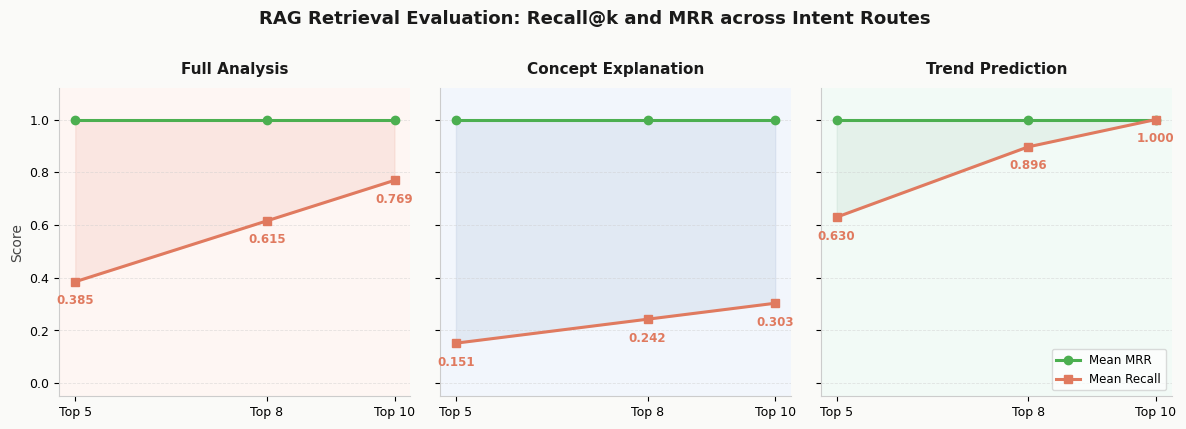

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

k_vals = [5, 8, 10]
# Mean recall and mrr scores from csv
data = {
    "Full Analysis": {
        "recall": [0.3846, 0.6154, 0.7692],
        "mrr":    [1.0,    1.0,    1.0],
        "color": "#E07A5F",
        "bg": "#FEF6F3",
    },
    "Concept Explanation": {
        "recall": [0.1515, 0.2424, 0.3030],
        "mrr":    [1.0,    1.0,    1.0],
        "color": "#6B8CBA",
        "bg": "#F2F6FC",
    },
    "Trend Prediction": {
        "recall": [0.6296, 0.8963, 1.0],
        "mrr":    [1.0,    1.0,    1.0],
        "color": "#81B29A",
        "bg": "#F2FAF6",
    },
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
fig.patch.set_facecolor("#FAFAF8")

for ax, (title, vals) in zip(axes, data.items()):
    ax.set_facecolor(vals["bg"])

    # Shaded band between recall and MRR
    ax.fill_between(k_vals, vals["recall"], vals["mrr"],
                    alpha=0.12, color=vals["color"])

    # MRR line
    ax.plot(k_vals, vals["mrr"], color="#4CAF50", linewidth=2.2,
            marker="o", markersize=6, label="Mean MRR", zorder=3)

    # Recall line
    ax.plot(k_vals, vals["recall"], color="#E07A5F", linewidth=2.2,
            marker="s", markersize=6, label="Mean Recall", zorder=3)

    # Annotate recall values
    for x, y in zip(k_vals, vals["recall"]):
        ax.annotate(f"{y:.3f}", (x, y),
                    textcoords="offset points", xytext=(0, -16),
                    ha="center", fontsize=8.5, color="#E07A5F",
                    fontweight="semibold")

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10, color="#1a1a1a")
    ax.set_xticks(k_vals)
    ax.set_xticklabels([f"Top {k}" for k in k_vals], fontsize=9)
    ax.set_ylim(-0.05, 1.12)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#cccccc")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5, color="#cccccc")

    if ax == axes[0]:
        ax.set_ylabel("Score", fontsize=10, color="#444")
    if ax == axes[2]:
        ax.legend(loc="lower right", fontsize=8.5, framealpha=0.7,
                  edgecolor="#cccccc")

fig.suptitle("RAG Retrieval Evaluation: Recall@k and MRR across Intent Routes",
             fontsize=13, fontweight="bold", y=1.01, color="#1a1a1a")

plt.tight_layout()
plt.savefig("rag_eval.png", bbox_inches="tight", dpi=200)
print("Done. Results saved to rag_eval.png")